# 触媒活性パラメータ `a` の補間解析

## 概要
本ノートブックでは、プロパン脱水素（PDH）プロセスにおける触媒活性パラメータ `a` の
時間・温度依存性を **2次元スプライン補間（RectBivariateSpline）** によりモデル化する。

### 採用手法の方針
- 数式フィッティング（多項式・指数関数など）は **一切使用しない**
- `scipy.interpolate.RectBivariateSpline`（kx=3, ky=3）により、**データ点上での誤差ゼロ**を保証する
- 使用データ：0〜30 分の範囲（短期挙動）に限定

### 対象データ
| 項目 | 内容 |
|------|------|
| ファイル | `data/a_parameter_fitting.xlsx` |
| 時間 `t` | 0, 5, 10, 15, 20, 25, 30 min（7点） |
| 温度 `T` | 400, 450, 500, 550, 600, 650, 700 °C（7点） |
| 活性 `a` | 0〜1（1.0 = 新鮮な触媒） |

## 1. 補間手法の選定根拠

### RectBivariateSpline を採用する理由

| 観点 | 理由 |
|------|------|
| **データ点完全再現** | スムージング係数 `s=0`（デフォルト）により、補間曲面は全データ点を誤差ゼロで通過する |
| **直交格子データとの相性** | 時間と温度が独立した格子（rectangular grid）を構成しているため `RectBivariateSpline` が最適 |
| **滑らかさの保証** | 3次スプライン（kx=ky=3）により、データ点間で $C^2$ 連続な滑らかな曲面が得られる |
| **補間の安定性** | 単変量スプラインを2方向に適用するため、ルンゲ現象（高次多項式フィットで生じる端点付近の発散）が発生しない |
| **シミュレータへの組み込みやすさ** | 学習済みオブジェクトを1回インスタンス化すれば、以降は `__call__` で高速に値を返せる |

### RectBivariateSpline の使い方

```
spline = RectBivariateSpline(T_arr, t_arr, A_matrix, kx=3, ky=3)
# -> A_matrix[i, j] = a( T_arr[i], t_arr[j] )

a_value = float(spline(T, t))  # スカラー評価
```

## 2. データの読み込みと格子データの構築

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import RectBivariateSpline

# ────────────────────────────────────────────────
# データ読み込み（monitor/ からの相対パス）
# ────────────────────────────────────────────────
DATA_PATH = "../data/a_parameter_fitting.xlsx"
df_raw = pd.read_excel(DATA_PATH)

# 列名を整理：最初の列を時間、残りを温度（°C）に対応させる
T_CELSIUS_LIST = [400, 450, 500, 550, 600, 650, 700]
df_raw.columns = ["t"] + T_CELSIUS_LIST

# ────────────────────────────────────────────────
# 0〜30 分のデータのみ抽出
# ────────────────────────────────────────────────
df_short = df_raw[df_raw["t"] <= 30].copy().reset_index(drop=True)

# t=0 のデータが含まれているか確認し、なければ補完
if 0 not in df_short["t"].values:
    row_t0 = {"t": 0}
    row_t0.update({T: 1.0 for T in T_CELSIUS_LIST})  # a(t=0) = 1.0 は物理的な初期条件
    df_short = pd.concat(
        [pd.DataFrame([row_t0]), df_short], ignore_index=True
    ).sort_values("t").reset_index(drop=True)
    print("t=0 のデータを a=1.0 で補完しました。")
else:
    print("t=0 のデータが存在します。補完は不要です。")

# ────────────────────────────────────────────────
# NumPy 配列として格子データを構築
# ────────────────────────────────────────────────
T_arr = np.array(T_CELSIUS_LIST, dtype=float)   # 温度軸 [°C]  (7点)
t_arr = df_short["t"].values.astype(float)       # 時間軸 [min] (7点)

# A_matrix[i, j] = a( T_arr[i], t_arr[j] )
# 行 = 温度インデックス、列 = 時間インデックス
A_matrix = np.array(
    [df_short[T].values for T in T_CELSIUS_LIST], dtype=float
)

print(f"\n温度軸 T_arr: {T_arr}")
print(f"時間軸 t_arr: {t_arr}")
print(f"A_matrix の形状: {A_matrix.shape}  (温度 × 時間)")
print("\nA_matrix（行=温度、列=時間）:")
df_display = pd.DataFrame(
    A_matrix,
    index=[f"{T}°C" for T in T_CELSIUS_LIST],
    columns=[f"t={int(t)}min" for t in t_arr],
)
print(df_display.to_string())

t=0 のデータが存在します。補完は不要です。

温度軸 T_arr: [400. 450. 500. 550. 600. 650. 700.]
時間軸 t_arr: [ 0.  5. 10. 15. 20. 25. 30.]
A_matrix の形状: (7, 7)  (温度 × 時間)

A_matrix（行=温度、列=時間）:
       t=0min  t=5min  t=10min  t=15min  t=20min  t=25min  t=30min
400°C     1.0    0.94     0.90    0.860     0.84     0.82     0.81
450°C     1.0    0.87     0.80    0.760     0.72     0.70     0.68
500°C     1.0    0.80     0.68    0.622     0.57     0.52     0.49
550°C     1.0    0.67     0.52    0.420     0.36     0.31     0.28
600°C     1.0    0.52     0.35    0.240     0.18     0.15     0.13
650°C     1.0    0.38     0.21    0.130     0.09     0.07     0.06
700°C     1.0    0.25     0.12    0.080     0.06     0.05     0.04


## 3. RectBivariateSpline の構築とデータ点完全再現の検証

スプラインオブジェクトを生成し、元データ点での残差がすべてゼロであることを確認する。

In [2]:
# ────────────────────────────────────────────────
# RectBivariateSpline の構築
#   x 軸 = 温度 T [°C]  (T_arr, 7点)
#   y 軸 = 時間 t [min] (t_arr, 7点)
#   z    = A_matrix[i, j] = a( T_arr[i], t_arr[j] )
#   kx=3, ky=3 : 3次スプライン（cubic）
#   s=0         : スムージングなし（全データ点を厳密に通過）
# ────────────────────────────────────────────────
spline = RectBivariateSpline(T_arr, t_arr, A_matrix, kx=3, ky=3)

# ────────────────────────────────────────────────
# スプライン評価のヘルパー関数
#   spline(T, t) はグリッド評価を返す（2D配列）ため、
#   スカラー評価には ev(xi, yi) メソッドを使用する。
#   ev() は 1D配列を返すので [0] で取り出す。
# ────────────────────────────────────────────────
def eval_spline(T_scalar: float, t_scalar: float) -> float:
    """スカラー (T, t) に対してスプライン値を返す"""
    return float(spline.ev(np.array([T_scalar]), np.array([t_scalar]))[0])

# ────────────────────────────────────────────────
# データ点上での残差検証
# ────────────────────────────────────────────────
print("データ点上での再現誤差（|a_spline - a_data|）:")
print(f"{'温度 [°C]':>10}  {'時間 [min]':>10}  {'実データ':>10}  {'スプライン':>11}  {'残差':>10}")
print("-" * 60)

max_err = 0.0
for i_T, T in enumerate(T_arr):
    for i_t, t in enumerate(t_arr):
        a_data   = A_matrix[i_T, i_t]
        a_spline = eval_spline(T, t)
        err      = abs(a_spline - a_data)
        max_err  = max(max_err, err)
        print(f"  {T:>8.0f}  {t:>10.0f}  {a_data:>10.4f}  {a_spline:>11.4f}  {err:>10.2e}")

print()
print(f"最大残差: {max_err:.2e}  （機械精度レベルであればデータ点完全再現を確認）")

データ点上での再現誤差（|a_spline - a_data|）:
   温度 [°C]    時間 [min]        実データ        スプライン          残差
------------------------------------------------------------
       400           0      1.0000       1.0000    4.44e-16
       400           5      0.9400       0.9400    3.33e-16
       400          10      0.9000       0.9000    2.22e-16
       400          15      0.8600       0.8600    2.22e-16
       400          20      0.8400       0.8400    1.11e-16
       400          25      0.8200       0.8200    3.33e-16
       400          30      0.8100       0.8100    1.11e-16
       450           0      1.0000       1.0000    4.44e-16
       450           5      0.8700       0.8700    4.44e-16
       450          10      0.8000       0.8000    1.11e-16
       450          15      0.7600       0.7600    2.22e-16
       450          20      0.7200       0.7200    0.00e+00
       450          25      0.7000       0.7000    1.11e-16
       450          30      0.6800       0.6800    1.11e-16
     

## 4. 補間結果の可視化

### 描画内容
1. **実データ（散布図）** と **スプライン補間カーブ（実線）** が完全に一致していることを示す
2. **既知温度外の補間（525 °C、点線）** を追加し、ルンゲ現象などの不自然な波打ちが生じていないことを確認する

<>:22: SyntaxWarning: invalid escape sequence '\c'
<>:35: SyntaxWarning: invalid escape sequence '\c'
<>:45: SyntaxWarning: invalid escape sequence '\c'
<>:22: SyntaxWarning: invalid escape sequence '\c'
<>:35: SyntaxWarning: invalid escape sequence '\c'
<>:45: SyntaxWarning: invalid escape sequence '\c'
C:\Users\yuish\AppData\Local\Temp\ipykernel_23192\2095916932.py:22: SyntaxWarning: invalid escape sequence '\c'
  ax.plot(t_fine, a_curve, color=color, lw=2, label=f"{T_C} $^\circ$C")
C:\Users\yuish\AppData\Local\Temp\ipykernel_23192\2095916932.py:35: SyntaxWarning: invalid escape sequence '\c'
  label=f"{T_unknown:.0f} $^\circ$C (interpolated)",
C:\Users\yuish\AppData\Local\Temp\ipykernel_23192\2095916932.py:45: SyntaxWarning: invalid escape sequence '\c'
  label=f"{T_ext} $^\circ$C (extrapolated)",


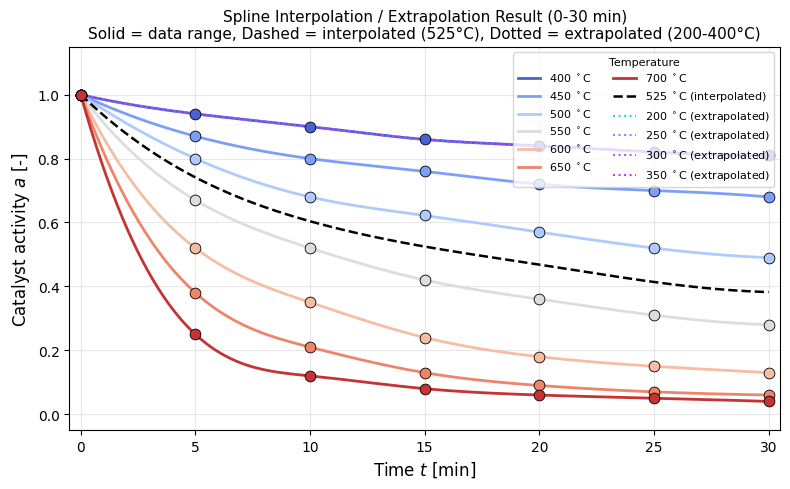

外挿値（t=0,5,10,15,20,25,30 min）:
  T [°C]  t= 0min  t= 5min  t=10min  t=15min  t=20min  t=25min  t=30min
-----------------------------------------------------------------------
     200   1.0000   0.9400   0.9000   0.8600   0.8400   0.8200   0.8100
     250   1.0000   0.9400   0.9000   0.8600   0.8400   0.8200   0.8100
     300   1.0000   0.9400   0.9000   0.8600   0.8400   0.8200   0.8100
     350   1.0000   0.9400   0.9000   0.8600   0.8400   0.8200   0.8100


In [3]:
# ────────────────────────────────────────────────
# 描画設定
# ────────────────────────────────────────────────
# 温度が高いほど赤系、低いほど青系になるカラーマップ
COLORS = plt.cm.coolwarm(np.linspace(0.05, 0.95, len(T_CELSIUS_LIST)))

# 補間カーブ描画用の連続時間点（0〜30 min）
t_fine = np.linspace(0, 30, 400)

# 外挿で確認したい温度（200〜400°C、データ範囲外）
T_EXTRAP_LIST = [200, 250, 300, 350]
COLORS_EXTRAP = plt.cm.cool(np.linspace(0.2, 0.8, len(T_EXTRAP_LIST)))

# ────────────────────────────────────────────────
# プロット本体
# ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

# --- 既知温度：実データ（散布図）とスプライン補間カーブ（実線）---
for i_T, (T_C, color) in enumerate(zip(T_CELSIUS_LIST, COLORS)):
    a_curve = spline.ev(np.full_like(t_fine, float(T_C)), t_fine)
    ax.plot(t_fine, a_curve, color=color, lw=2, label=f"{T_C} $^\circ$C")
    ax.scatter(
        t_arr, A_matrix[i_T, :],
        color=color, s=60, zorder=5,
        edgecolors="black", linewidths=0.6,
    )

# --- 未知温度 525 °C の補間カーブ（点線）---
T_unknown = 525.0
a_unknown = spline.ev(np.full_like(t_fine, T_unknown), t_fine)
ax.plot(
    t_fine, a_unknown,
    color="black", lw=1.8, linestyle="--",
    label=f"{T_unknown:.0f} $^\circ$C (interpolated)",
    zorder=4,
)

# --- データ範囲外の外挿カーブ（200〜400°C、点線）---
for T_ext, color_ext in zip(T_EXTRAP_LIST, COLORS_EXTRAP):
    a_ext = spline.ev(np.full_like(t_fine, float(T_ext)), t_fine)
    ax.plot(
        t_fine, a_ext,
        color=color_ext, lw=1.5, linestyle=":",
        label=f"{T_ext} $^\circ$C (extrapolated)",
        zorder=3,
    )

# ────────────────────────────────────────────────
# 軸・凡例の設定
# ────────────────────────────────────────────────
ax.set_xlabel("Time $t$ [min]", fontsize=12)
ax.set_ylabel("Catalyst activity $a$ [-]", fontsize=12)
ax.set_title(
    "Spline Interpolation / Extrapolation Result (0-30 min)\n"
    "Solid = data range, Dashed = interpolated (525°C), Dotted = extrapolated (200-400°C)",
    fontsize=11,
)
ax.set_xlim(-0.5, 30.5)
ax.set_ylim(-0.05, 1.15)
ax.legend(
    title="Temperature", fontsize=8, title_fontsize=8,
    loc="upper right", ncol=2,
)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ────────────────────────────────────────────────
# 外挿値の数値確認
# ────────────────────────────────────────────────
print("外挿値（t=0,5,10,15,20,25,30 min）:")
header = f"{'T [°C]':>8}" + "".join(f"  t={int(t):>2}min" for t in t_arr)
print(header)
print("-" * len(header))
for T_ext in T_EXTRAP_LIST:
    vals = [eval_spline(float(T_ext), float(t)) for t in t_arr]
    row = f"{T_ext:>8}" + "".join(f"  {v:>7.4f}" for v in vals)
    print(row)

## 5. まとめ

### フィッティング結果（ハードコード用マトリクス）

以下の配列を `src/catalyst_model.py` にそのまま埋め込む。

```python
T_ARR = [400, 450, 500, 550, 600, 650, 700]   # °C
t_ARR = [0, 5, 10, 15, 20, 25, 30]            # min

A_MATRIX = [
    [1.00, 0.94, 0.90, 0.86, 0.84, 0.82, 0.81],   # 400 °C
    [1.00, 0.87, 0.80, 0.76, 0.72, 0.70, 0.68],   # 450 °C
    [1.00, 0.80, 0.68, 0.622, 0.570, 0.520, 0.490],  # 500 °C
    [1.00, 0.67, 0.52, 0.42, 0.36, 0.31, 0.28],   # 550 °C
    [1.00, 0.52, 0.35, 0.24, 0.18, 0.15, 0.13],   # 600 °C
    [1.00, 0.38, 0.21, 0.13, 0.09, 0.07, 0.06],   # 650 °C
    [1.00, 0.25, 0.12, 0.08, 0.06, 0.05, 0.04],   # 700 °C
]
```

### 安全処理（クリッピング）の設計

| 対象 | 処理 | 理由 |
|------|------|------|
| 入力 T | `clip(T, 400, 700)` | 外挿はスプラインの信頼性が低下するため |
| 入力 t | `clip(t, 0, 30)` | 補間対象データの範囲外 |
| 出力 a | `clip(a, 0.0, 1.0)` | 物理的に a は 0〜1 の範囲でなければならない |